# **Start**

In [ ]:
import numpy as np
import joblib
import tensorflow as tf
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
print("Connecting to Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
print("Drive connected.")

Connecting to Google Drive...
Mounted at /content/drive
Drive connected.


In [ ]:

processed_data_path = "/content/drive/My Drive/Internship_project/cnn_prepared_patches_15.npz"
scaler_save_path = "/content/drive/My Drive/Internship_project/model_15/cnn_scaler_15.joblib"
model_save_path = "/content/drive/My Drive/Internship_project/model_15/cnn_lulc_model_final_15.keras"

NUM_CLASSES = 6

CLASS_NAMES = [
        'Forest',       # 0
        'Water',        # 1
        'Agriculture',  # 2
        'Settlement',   # 3
        'Mining',       # 4
        'Barren'        # 5
    ]

BATCH_SIZE = 128

In [ ]:

class DataGenerator(Sequence):
    """
    Generates batches of data on-the-fly.
    This improved version opens the data file only once for efficiency.
    """
    def __init__(self, npz_path, list_IDs, y_data, scaler, batch_size, num_classes):
        self.npz_path = npz_path
        self.list_IDs = list_IDs
        self.y_data = y_data
        self.scaler = scaler
        self.batch_size = batch_size
        self.num_classes = num_classes
        # Open the memory-mapped file handle ONCE and keep it open
        self.npz_file = np.load(self.npz_path, 'r')
        self.x_data_mmap = self.npz_file['x_data']
        self.on_epoch_end()

    def __len__(self):
        """Returns the number of batches per epoch."""
        return math.ceil(len(self.list_IDs) / self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data."""
        indexes = self.list_IDs[index * self.batch_size:(index + 1) * self.batch_size]
        X, y = self.__data_generation(indexes)
        return X, y

    def on_epoch_end(self):
        """Shuffles indexes at the end of each epoch."""
        np.random.shuffle(self.list_IDs)

    def __data_generation(self, list_IDs_temp):
        """Generates data containing batch_size samples."""
        # Use the persistent file handle instead of re-opening
        X_batch = self.x_data_mmap[list_IDs_temp].astype(np.float32)
        y_batch_labels = self.y_data[list_IDs_temp]

        X_batch = np.nan_to_num(X_batch, nan=0.0, posinf=0.0, neginf=0.0)
        h, w, num_bands = X_batch.shape[1], X_batch.shape[2], X_batch.shape[3]
        X_reshaped = X_batch.reshape(-1, num_bands)
        X_scaled = self.scaler.transform(X_reshaped)
        X_final = X_scaled.reshape(-1, h, w, num_bands)
        y_final = to_categorical(y_batch_labels, num_classes=self.num_classes)
        return X_final, y_final

    def close(self):
        self.npz_file.close()

In [ ]:

print("Preparing data indices and scaler...")

with np.load(processed_data_path, 'r') as data:
    y_data = data['y_data']
    x_shape = data['x_data'].shape
    num_samples = x_shape[0]
    patch_size_h, patch_size_w, num_bands = x_shape[1], x_shape[2], x_shape[3]
print(f"Dataset has {num_samples} samples.")

print("Fitting StandardScaler in chunks to conserve memory...")
scaler = StandardScaler()
chunk_size = 2000 # Process 2000 samples at a time
with np.load(processed_data_path, 'r') as data:
    x_data_mmap = data['x_data']
    for i in range(0, num_samples, chunk_size):
        chunk = x_data_mmap[i:i + chunk_size].astype(np.float32)
        chunk = np.nan_to_num(chunk)
        scaler.partial_fit(chunk.reshape(-1, num_bands))
print("Scaler fitted successfully.")
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

indices = np.arange(num_samples)

# Split indices and labels into train, validation, and test sets
y_labels_for_stratify = y_data
y_cat_for_stratify = to_categorical(y_labels_for_stratify, num_classes=NUM_CLASSES)

# First split (80% train+val, 20% test)
train_val_indices, test_indices, _, y_test_labels_s = train_test_split(
    indices, y_cat_for_stratify, test_size=0.20, random_state=42, stratify=y_cat_for_stratify
)

# Second split (60% train, 20% validation)
train_indices, val_indices = train_test_split(
    train_val_indices, test_size=0.25, random_state=42, stratify=y_cat_for_stratify[train_val_indices]
)

# Instantiate the generators
training_generator = DataGenerator(processed_data_path, train_indices, y_data, scaler, BATCH_SIZE, NUM_CLASSES)
validation_generator = DataGenerator(processed_data_path, val_indices, y_data, scaler, BATCH_SIZE, NUM_CLASSES)
testing_generator = DataGenerator(processed_data_path, test_indices, y_data, scaler, BATCH_SIZE, NUM_CLASSES)

print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")
print("Data preparation complete.")

Preparing data indices and scaler...
Dataset has 123418 samples.
Fitting StandardScaler in chunks to conserve memory...
Scaler fitted successfully.
Scaler saved to /content/drive/My Drive/Internship_project/model_15/cnn_scaler_15.joblib
Training samples: 74050
Validation samples: 24684
Test samples: 24684
Data preparation complete.


In [ ]:

print("\nBuilding the CNN model...")

print(f"Input shape for model: ({patch_size_h}, {patch_size_w}, {num_bands})")

model = Sequential([
    # IMPORTANT: The input_shape is now correctly defined
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(patch_size_h, patch_size_w, num_bands)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout helps prevent overfitting
    Dense(NUM_CLASSES, activation='softmax') # Softmax for multi-class classification
])

# Use the recommended stable optimizer and compile the model
optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()





Building the CNN model...
Input shape for model: (15, 15, 11)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 15, 15, 32)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 15, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,734 (444.27 KB)

 Trainable params: 113,286 (442.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("\nStarting model training with data generators...")

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,    # Reduce LR by a factor of 5
                              patience=3,    # Number of epochs with no improvement before reducing LR
                              verbose=1,     # Print a message when LR is reduced
                              min_lr=0.00001) # Minimum learning rate
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    model_save_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[reduce_lr, checkpoint]
)

model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Starting model training with data generators...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


569/579 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9610 - loss: 0.1287

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 0.00964, saving model to /content/drive/My Drive/Internship_project/model_15/cnn_lulc_model_final_15.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9615 - loss: 0.1272 - val_accuracy: 0.9971 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 2/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9951 - loss: 0.0156
Epoch 2: val_loss did not improve from 0.00964
579/579 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9878 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 3/20
578/579 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9973 - loss: 0.0094
Epoch 3: val_loss improved from 0.00964 to 0.00185, saving model to /content/drive/My Drive/Internship_project/model_15/cnn_lulc_model_final_15.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9973 - loss: 0.0094 - val_accuracy: 0.9994 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 4/20
577/579 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accu


--- Starting Bulletproof Evaluation ---
Iterating through the test generator ONCE to get predictions and labels...
Processed batch 10/193
Processed batch 20/193
Processed batch 30/193
Processed batch 40/193
Processed batch 50/193
Processed batch 60/193
Processed batch 70/193
Processed batch 80/193
Processed batch 90/193
Processed batch 100/193
Processed batch 110/193
Processed batch 120/193
Processed batch 130/193
Processed batch 140/193
Processed batch 150/193
Processed batch 160/193
Processed batch 170/193
Processed batch 180/193
Processed batch 190/193

--- Final, Trustworthy Results ---

TRUE Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Forest       1.00      1.00      1.00      4022
       Water       1.00      1.00      1.00      4918
 Agriculture       1.00      1.00      1.00      4506
  Settlement       1.00      1.00      1.00      4281
      Mining       1.00      1.00      1.00       988
      Barren       1.00 

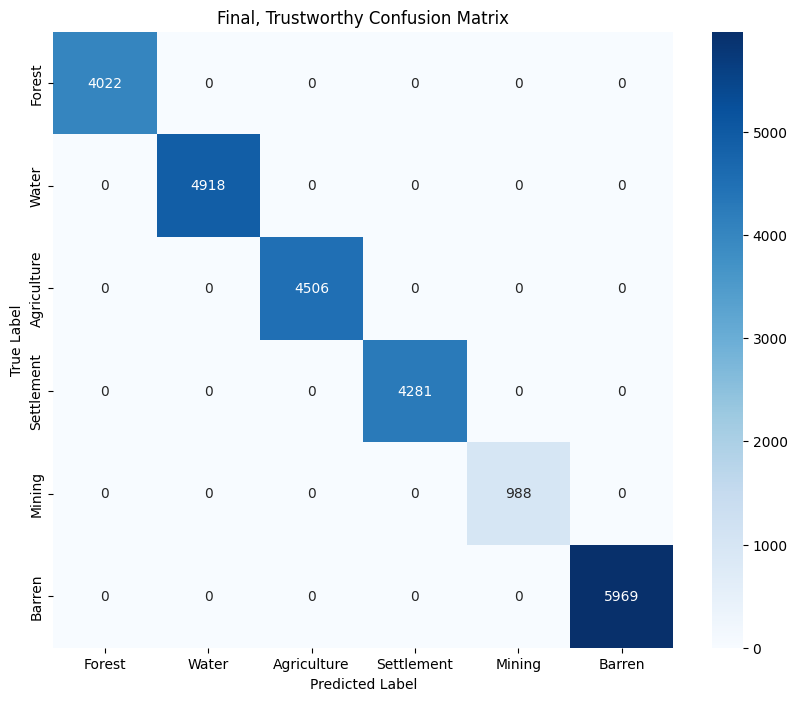


✅ Evaluation complete!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Starting Bulletproof Evaluation ---")
print("Iterating through the test generator ONCE to get predictions and labels...")

all_predictions = []
all_true_labels = []

# Ensure the generator is at the start
testing_generator.on_epoch_end()

# Loop through every batch in the generator
for i in range(len(testing_generator)):
    # Get one batch of data and its true labels
    X_batch, y_batch_one_hot = testing_generator[i]

    # Make predictions on this single batch
    # Using predict_on_batch is efficient for manual loops
    preds_batch = model.predict_on_batch(X_batch)

    # Convert predictions (probabilities) and true labels (one-hot) to class indices
    preds_classes = np.argmax(preds_batch, axis=1)
    true_classes = np.argmax(y_batch_one_hot, axis=1)

    # Append the results from this batch to our master lists
    all_predictions.extend(preds_classes)
    all_true_labels.extend(true_classes)

    # Optional: Print progress so you know it's working
    if (i + 1) % 10 == 0:
        print(f"Processed batch {i + 1}/{len(testing_generator)}")

# Convert the lists to NumPy arrays for calculations
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# --- Final, Reliable Results ---
# Now that we have perfectly aligned arrays, calculate everything.
print("\n--- Final, Trustworthy Results ---")

# 1. Overall Accuracy Score
# This will be the TRUE accuracy of your model.
final_accuracy = accuracy_score(all_true_labels, all_predictions)
print(f"\nTRUE Test Accuracy: {final_accuracy:.4f}")

# 2. Classification Report
print("\nClassification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=CLASS_NAMES))

# 3. Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Final, Trustworthy Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Close the file handle for the testing generator
testing_generator.close()

print("\n✅ Evaluation complete!")